In [ ]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110


In [ ]:
#  LOAD DATASET
df = pd.read_csv("googleplaystore.csv")

print("=" * 55)
print("📱 GOOGLE PLAY STORE - EDA")
print("=" * 55)
print(f"Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns     : {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nNull Values:")
print(df.isnull().sum())

📱 GOOGLE PLAY STORE - EDA
Shape       : 10,841 rows × 13 columns
Columns     : ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

First 5 rows:
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free   

In [ ]:
#  DATA CLEANING & PREPROCESSING

# --- Remove Duplicates ---
before = len(df)
df.drop_duplicates(subset="App", inplace=True)
print(f"\n✂️  Duplicates removed: {before - len(df)}")

# --- Remove known corrupt row (Category = '1.9') ---
df = df[df["Category"] != "1.9"]

# --- Rating: convert to numeric & keep valid range (0–5) ---
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df = df[df["Rating"].between(0, 5) | df["Rating"].isna()]



✂️  Duplicates removed: 1181


In [ ]:
# --- Reviews: convert to numeric ---
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

# --- Installs: remove '+' and ',' → numeric ---
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(r"[+,]", "", regex=True)
    .str.replace("Free", "", regex=False)
    .apply(pd.to_numeric, errors="coerce")
)

In [ ]:
#  Price: remove '$' → numeric
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace("Free", "0", regex=False)
    .str.replace("Everyone", "", regex=False)
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)

In [ ]:
# --- Size: convert to MB ---
def size_to_mb(x):
    if pd.isnull(x):
        return np.nan
    x = str(x).strip()
    if x == "Varies with device":
        return np.nan
    if "M" in x:
        return float(x.replace("M", ""))
    if "k" in x:
        return float(x.replace("k", "")) / 1024
    return np.nan

df["Size"] = df["Size"].apply(size_to_mb)

In [ ]:
# --- Last Updated: convert to datetime ---
df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")
df["Update_Year"]  = df["Last Updated"].dt.year
df["Update_Month"] = df["Last Updated"].dt.month

In [ ]:
# --- Standardize text fields ---
df["Category"] = df["Category"].str.strip().str.upper()
df["Type"]     = df["Type"].str.strip().str.capitalize()

print("\n✅ Data Cleaning Complete!")
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")


✅ Data Cleaning Complete!
Final shape: 9,659 rows × 15 columns



BASIC-LEVEL QUESTIONS

In [ ]:
#  Q1. Average rating of apps
avg_rating = df["Rating"].mean()
print(f"\n[Q1] Average Rating of Apps: {avg_rating:.2f}")


[Q1] Average Rating of Apps: 4.17


In [ ]:
#  Q2. Unique categories
unique_cats = df["Category"].nunique()
print(f"\n[Q2] Unique App Categories: {unique_cats}")
print(df["Category"].unique())


[Q2] Unique App Categories: 33
['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION']


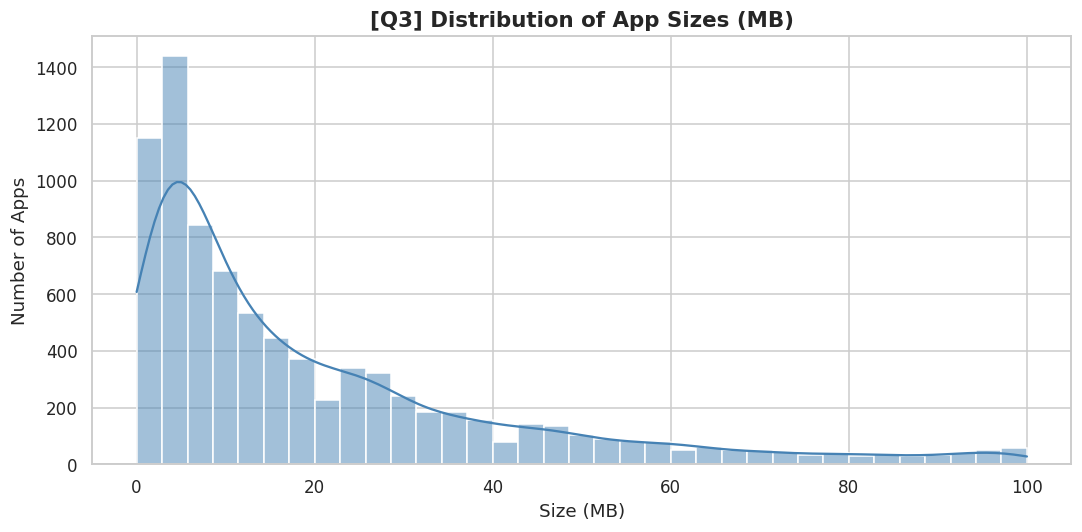


[Q3] App Size Distribution plotted → q3_app_size_dist.png


In [ ]:
#  Q3. Distribution of app sizes
plt.figure(figsize=(10, 5))
sns.histplot(df["Size"].dropna(), bins=35, kde=True, color="steelblue")
plt.title("[Q3] Distribution of App Sizes (MB)", fontsize=14, fontweight="bold")
plt.xlabel("Size (MB)")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.savefig("q3_app_size_dist.png", bbox_inches="tight")
plt.show()
print("\n[Q3] App Size Distribution plotted → q3_app_size_dist.png")


[Q4] Free vs Paid Apps:
Type
Free    8902
Paid     756


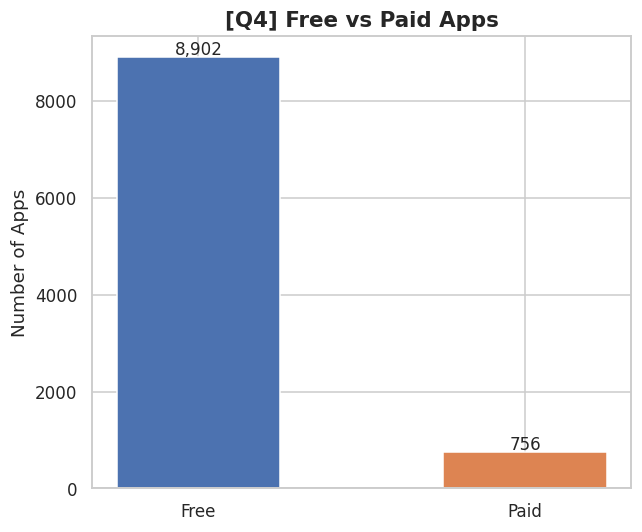

In [ ]:
#  Q4. Free vs Paid apps
type_counts = df["Type"].value_counts()
print(f"\n[Q4] Free vs Paid Apps:\n{type_counts.to_string()}")

plt.figure(figsize=(6, 5))
bars = plt.bar(type_counts.index, type_counts.values,
               color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50,
             f"{bar.get_height():,}", ha="center", fontsize=11)
plt.title("[Q4] Free vs Paid Apps", fontsize=14, fontweight="bold")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.savefig("q4_free_vs_paid.png", bbox_inches="tight")
plt.show()


[Q5] Most Common Content Rating: 'Everyone'
Content Rating
Everyone           7903
Teen               1036
Mature 17+          393
Everyone 10+        322
Adults only 18+       3
Unrated               2


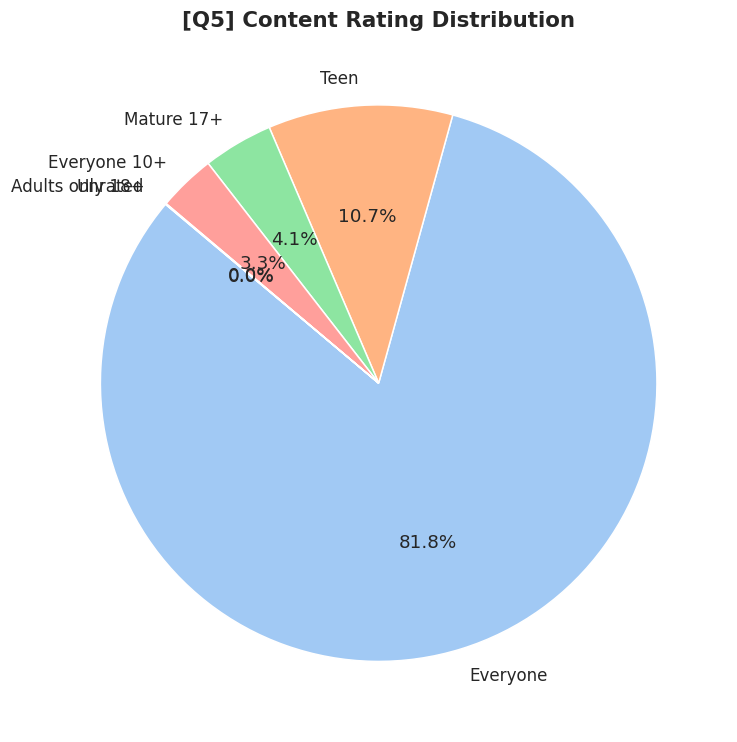

In [ ]:
#  Q5. Most common content rating
most_common_cr = df["Content Rating"].mode()[0]
cr_counts = df["Content Rating"].value_counts()
print(f"\n[Q5] Most Common Content Rating: '{most_common_cr}'")
print(cr_counts.to_string())

plt.figure(figsize=(7, 7))
plt.pie(cr_counts.values, labels=cr_counts.index, autopct="%1.1f%%",
        startangle=140, colors=sns.color_palette("pastel", len(cr_counts)))
plt.title("[Q5] Content Rating Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("q5_content_rating.png", bbox_inches="tight")
plt.show()

In [ ]:
#  Q6. Top 5 most installed apps
top5_installed = (
    df.dropna(subset=["Installs"])
    .nlargest(5, "Installs")[["App", "Installs", "Category", "Rating"]]
)
print(f"\n[Q6] Top 5 Most Installed Apps:")
print(top5_installed.to_string(index=False))


[Q6] Top 5 Most Installed Apps:
                                     App   Installs            Category  Rating
                       Google Play Books 1000000000 BOOKS_AND_REFERENCE     3.9
Messenger – Text and Video Chat for Free 1000000000       COMMUNICATION     4.0
                      WhatsApp Messenger 1000000000       COMMUNICATION     4.4
            Google Chrome: Fast & Secure 1000000000       COMMUNICATION     4.3
                                   Gmail 1000000000       COMMUNICATION     4.3


In [ ]:
#  Q7. Apps with rating >= 4.0
high_rated = df[df["Rating"] >= 4.0]
print(f"\n[Q7] Apps with Rating ≥ 4.0: {len(high_rated):,}")
print(f"      That's {len(high_rated)/len(df)*100:.1f}% of all apps")


[Q7] Apps with Rating ≥ 4.0: 6,286
      That's 65.1% of all apps



[Q8] Average Reviews — Free vs Paid:
Type
Free    234270.002134
Paid      8724.887566


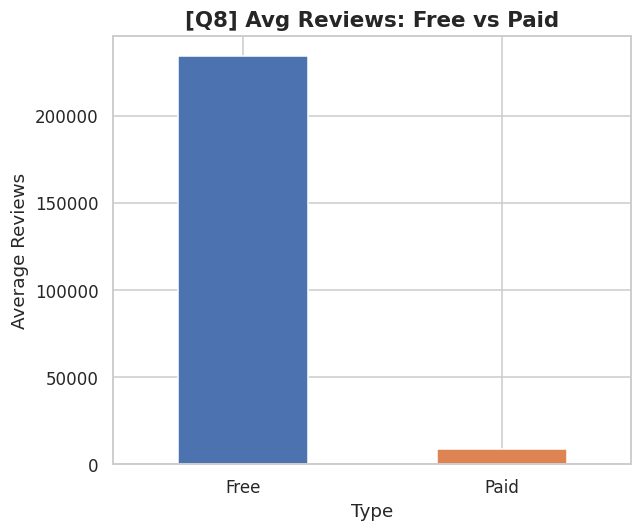

In [ ]:
#  Q8. Average reviews: Free vs Paid
avg_reviews = (
    df[df["Type"].isin(["Free", "Paid"])]
    .groupby("Type")["Reviews"]
    .mean()
)
print(f"\n[Q8] Average Reviews — Free vs Paid:")
print(avg_reviews.to_string())

plt.figure(figsize=(6, 5))
avg_reviews.plot(kind="bar", color=["#4C72B0", "#DD8452"],
                 edgecolor="white", width=0.5)
plt.title("[Q8] Avg Reviews: Free vs Paid", fontsize=14, fontweight="bold")
plt.ylabel("Average Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("q8_avg_reviews_type.png", bbox_inches="tight")
plt.show()


[Q9] Average App Size per Category (Top 15):
Category
GAME                   41.866570
FAMILY                 27.187747
TRAVEL_AND_LOCAL       24.204375
SPORTS                 24.058153
ENTERTAINMENT          23.043750
PARENTING              22.512963
HEALTH_AND_FITNESS     20.669296
FOOD_AND_DRINK         20.494318
AUTO_AND_VEHICLES      20.036807
MEDICAL                19.188756
EDUCATION              19.056816
FINANCE                17.367863
MAPS_AND_NAVIGATION    16.367773
SOCIAL                 15.983868
HOUSE_AND_HOME         15.970010


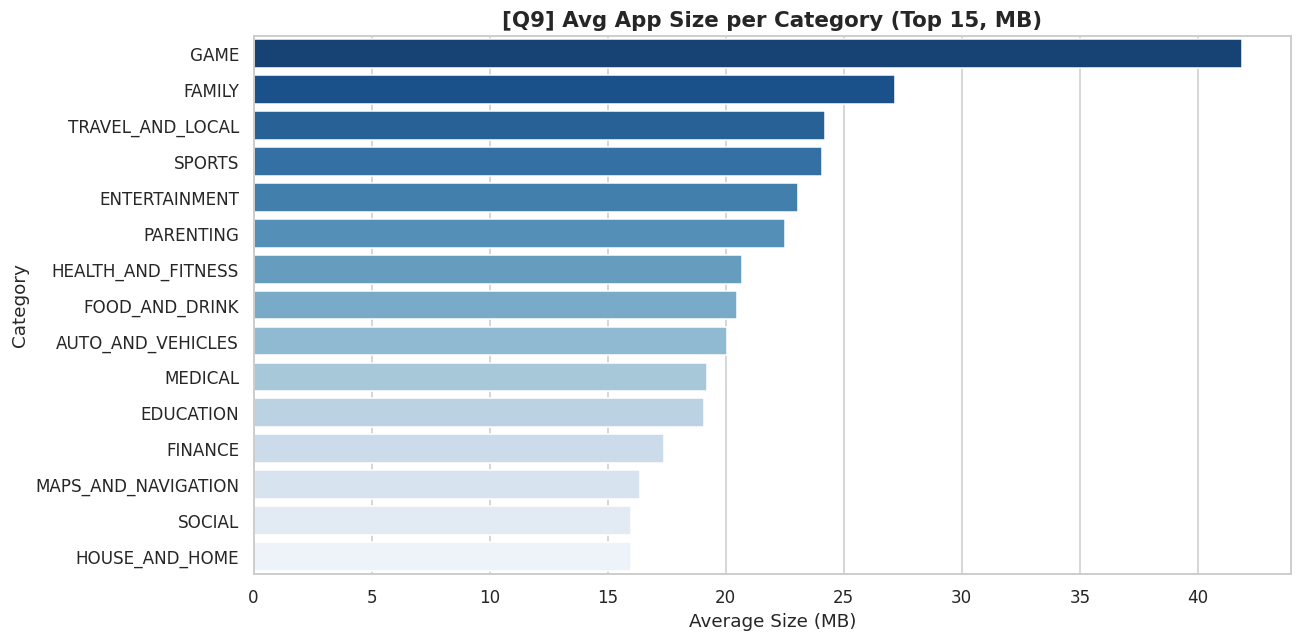

In [ ]:
#  Q9. Average app size per category
avg_size_cat = (
    df.groupby("Category")["Size"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
print(f"\n[Q9] Average App Size per Category (Top 15):")
print(avg_size_cat.to_string())

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_size_cat.values, y=avg_size_cat.index, palette="Blues_r")
plt.title("[Q9] Avg App Size per Category (Top 15, MB)", fontsize=14, fontweight="bold")
plt.xlabel("Average Size (MB)")
plt.tight_layout()
plt.savefig("q9_avg_size_category.png", bbox_inches="tight")
plt.show()

In [ ]:
#  Q10. Apps updated in 2018
apps_2018 = df[df["Update_Year"] == 2018]
print(f"\n[Q10] Apps Last Updated in 2018: {len(apps_2018):,}")


[Q10] Apps Last Updated in 2018: 6,284


MEDIUM-LEVEL QUESTIONS


[M1] Correlation between Installs and Rating: 0.0401


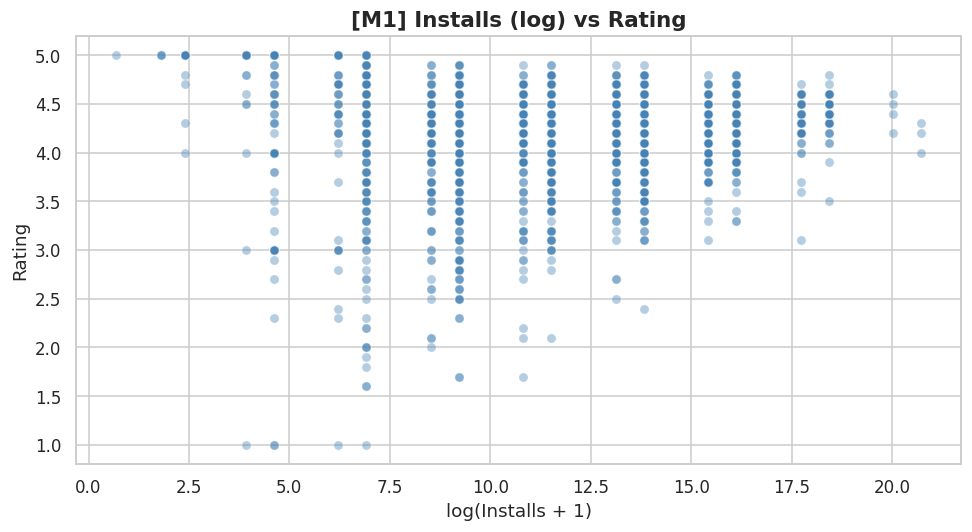

In [ ]:
 # Correlation: Installs vs Rating
corr_val = df[["Installs", "Rating"]].dropna().corr().iloc[0, 1]
print(f"\n[M1] Correlation between Installs and Rating: {corr_val:.4f}")

plt.figure(figsize=(9, 5))
sample = df.dropna(subset=["Installs", "Rating"]).sample(2000, random_state=42)
sns.scatterplot(x=np.log1p(sample["Installs"]), y=sample["Rating"],
                alpha=0.4, color="steelblue")
plt.title("[M1] Installs (log) vs Rating", fontsize=14, fontweight="bold")
plt.xlabel("log(Installs + 1)")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig("m1_installs_vs_rating.png", bbox_inches="tight")
plt.show()


[M2] Top 10 Categories by Average Rating:
           Category   Rating
             EVENTS 4.435556
          EDUCATION 4.364407
     ART_AND_DESIGN 4.357377
BOOKS_AND_REFERENCE 4.344970
    PERSONALIZATION 4.332215
          PARENTING 4.300000
             BEAUTY 4.278571
               GAME 4.247368
             SOCIAL 4.247291
            WEATHER 4.243056


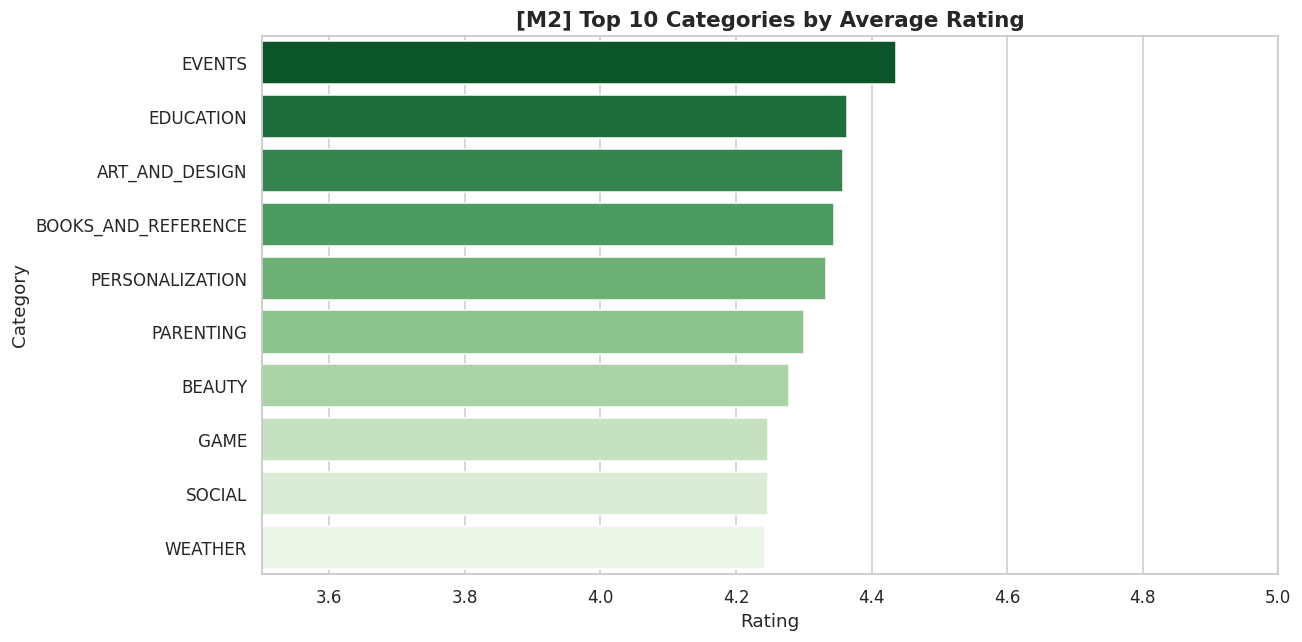

In [ ]:
#  Categories with highest avg rating
cat_rating = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
print(f"\n[M2] Top 10 Categories by Average Rating:")
print(cat_rating.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=cat_rating, x="Rating", y="Category", palette="Greens_r")
plt.title("[M2] Top 10 Categories by Average Rating", fontsize=14, fontweight="bold")
plt.xlim(3.5, 5.0)
plt.tight_layout()
plt.savefig("m2_category_avg_rating.png", bbox_inches="tight")
plt.show()


[M3] Price vs Avg Rating (Paid apps, price < $50):
 Price   Rating
  0.99 4.298077
  1.00 4.450000
  1.04      NaN
  1.20 4.200000
  1.26      NaN
  1.29 4.100000
  1.49 4.196774
  1.50 4.200000
  1.59 4.500000
  1.61 4.200000


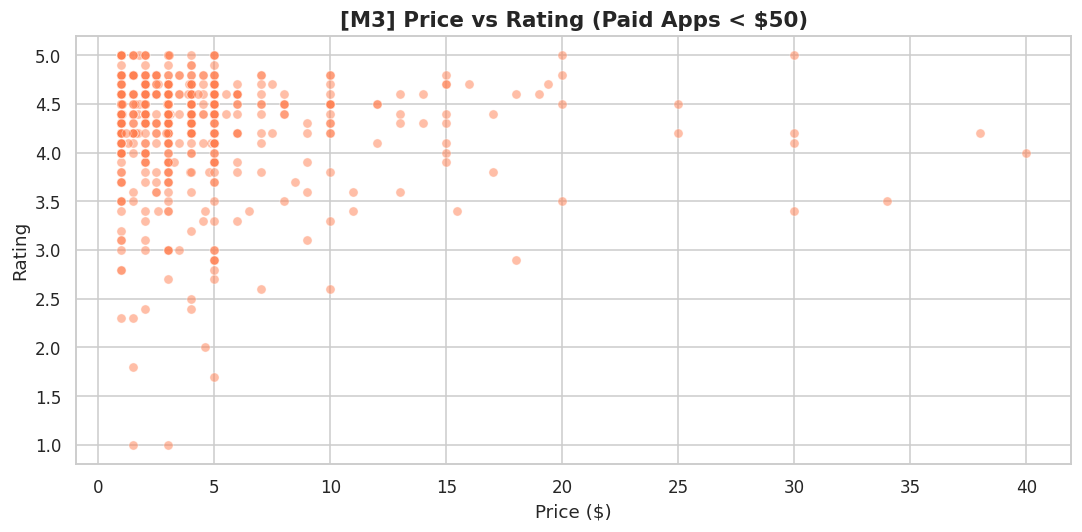

In [ ]:
# Price vs Average Rating (Paid apps)
paid_df = df[(df["Type"] == "Paid") & (df["Price"] > 0) & (df["Price"] < 50)]
price_rating = paid_df.groupby("Price")["Rating"].mean().reset_index()
print(f"\n[M3] Price vs Avg Rating (Paid apps, price < $50):")
print(price_rating.head(10).to_string(index=False))

plt.figure(figsize=(10, 5))
sns.scatterplot(data=paid_df, x="Price", y="Rating", alpha=0.5, color="coral")
plt.title("[M3] Price vs Rating (Paid Apps < $50)", fontsize=14, fontweight="bold")
plt.xlabel("Price ($)")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig("m3_price_vs_rating.png", bbox_inches="tight")
plt.show()

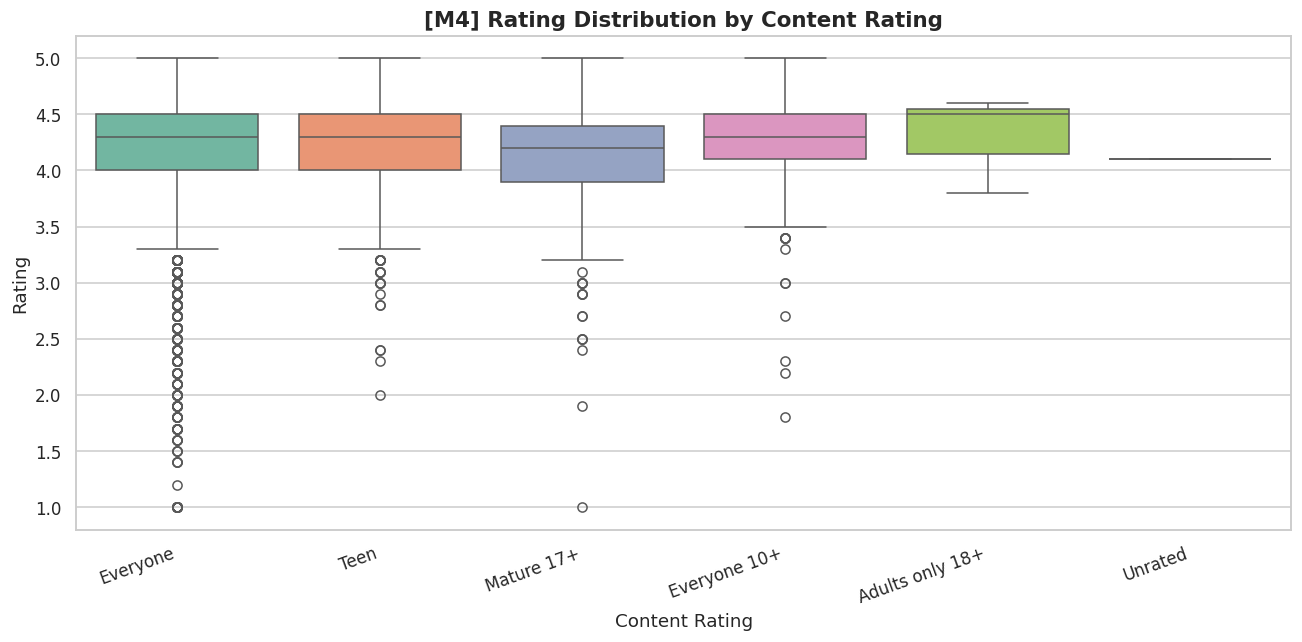


[M4] Boxplot plotted → m4_rating_by_content.png


In [ ]:
#  Rating distribution across Content Ratings
plt.figure(figsize=(12, 6))
order = df["Content Rating"].value_counts().index
sns.boxplot(data=df.dropna(subset=["Rating", "Content Rating"]),
            x="Content Rating", y="Rating", order=order, palette="Set2")
plt.title("[M4] Rating Distribution by Content Rating", fontsize=14, fontweight="bold")
plt.xlabel("Content Rating")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("m4_rating_by_content.png", bbox_inches="tight")
plt.show()
print("\n[M4] Boxplot plotted → m4_rating_by_content.png")


[M5] Top 10 Genres with Apps > 1M Installs:
Genres
Tools            172
Action           128
Photography      123
Communication     99
Productivity      91
Entertainment     83
Arcade            81
Sports            79
Shopping          72
Social            67


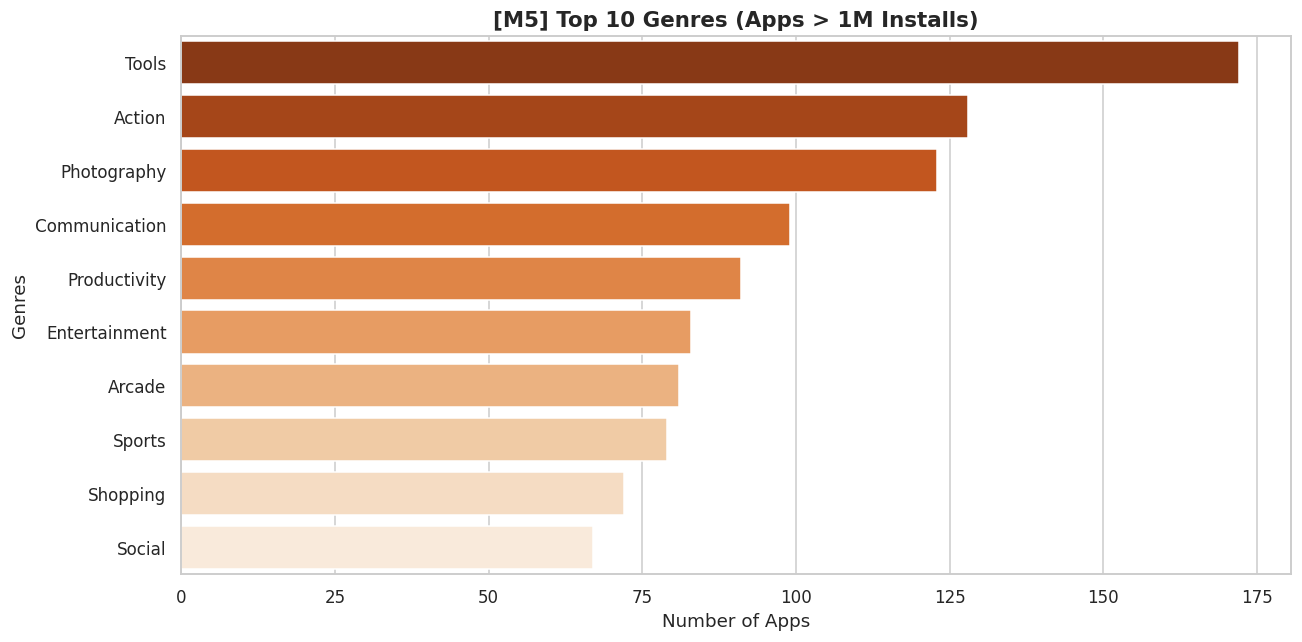

In [ ]:
 # Genres with most apps > 1M installs
high_install = df[df["Installs"] > 1_000_000]
genre_counts = high_install["Genres"].value_counts().head(10)
print(f"\n[M5] Top 10 Genres with Apps > 1M Installs:")
print(genre_counts.to_string())

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="Oranges_r")
plt.title("[M5] Top 10 Genres (Apps > 1M Installs)", fontsize=14, fontweight="bold")
plt.xlabel("Number of Apps")
plt.tight_layout()
plt.savefig("m5_genres_high_installs.png", bbox_inches="tight")
plt.show()


[M6] Average Days Since Last Update: 281 days


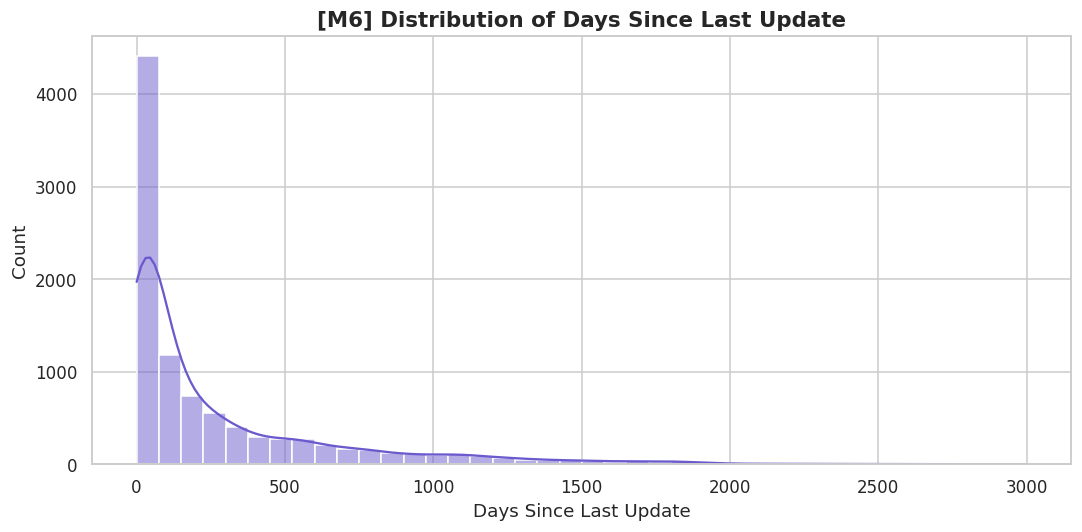

In [ ]:
#  App update frequency
# How many days since last update (from max date as reference)
df_dated = df.dropna(subset=["Last Updated"]).copy()
ref_date  = df_dated["Last Updated"].max()
df_dated["Days_Since_Update"] = (ref_date - df_dated["Last Updated"]).dt.days

avg_days = df_dated["Days_Since_Update"].mean()
print(f"\n[M6] Average Days Since Last Update: {avg_days:.0f} days")

plt.figure(figsize=(10, 5))
sns.histplot(df_dated["Days_Since_Update"], bins=40, kde=True, color="slateblue")
plt.title("[M6] Distribution of Days Since Last Update", fontsize=14, fontweight="bold")
plt.xlabel("Days Since Last Update")
plt.tight_layout()
plt.savefig("m6_update_frequency.png", bbox_inches="tight")
plt.show()

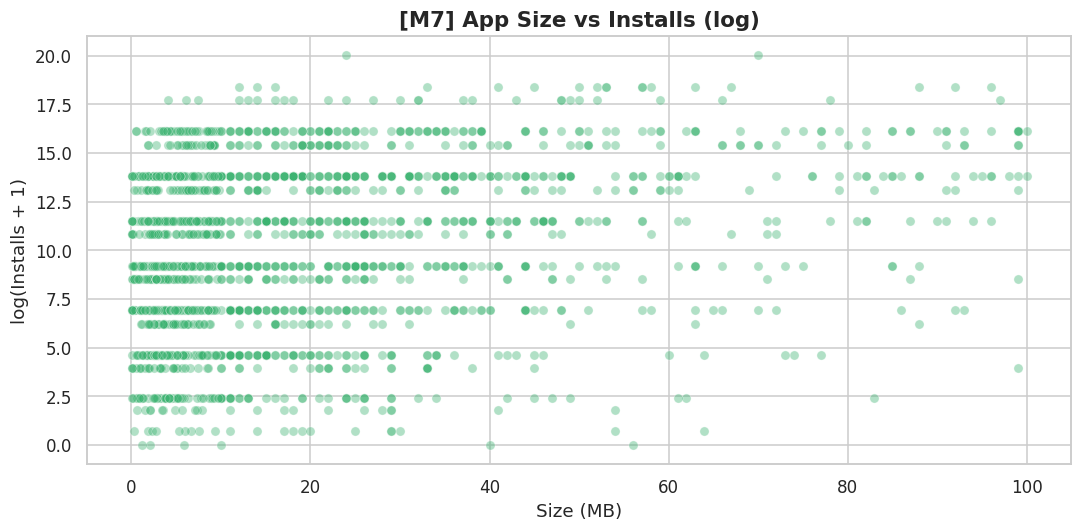


[M7] Scatter plot saved → m7_size_vs_installs.png


In [ ]:
#  App Size vs Installs
plt.figure(figsize=(10, 5))
sample_m7 = df.dropna(subset=["Size", "Installs"]).sample(2000, random_state=1)
sns.scatterplot(x=sample_m7["Size"],
                y=np.log1p(sample_m7["Installs"]),
                alpha=0.4, color="mediumseagreen")
plt.title("[M7] App Size vs Installs (log)", fontsize=14, fontweight="bold")
plt.xlabel("Size (MB)")
plt.ylabel("log(Installs + 1)")
plt.tight_layout()
plt.savefig("m7_size_vs_installs.png", bbox_inches="tight")
plt.show()
print("\n[M7] Scatter plot saved → m7_size_vs_installs.png")

In [ ]:
#  Highest reviewed apps and their ratings
top_reviewed = (
    df.dropna(subset=["Reviews"])
    .nlargest(10, "Reviews")[["App", "Reviews", "Rating", "Category"]]
)
print(f"\n[M8] Top 10 Most Reviewed Apps:")
print(top_reviewed.to_string(index=False))


[M8] Top 10 Most Reviewed Apps:
                                               App  Reviews  Rating      Category
                                          Facebook 78158306     4.1        SOCIAL
                                WhatsApp Messenger 69119316     4.4 COMMUNICATION
                                         Instagram 66577313     4.5        SOCIAL
          Messenger – Text and Video Chat for Free 56642847     4.0 COMMUNICATION
                                    Clash of Clans 44891723     4.6          GAME
           Clean Master- Space Cleaner & Antivirus 42916526     4.7         TOOLS
                                    Subway Surfers 27722264     4.5          GAME
                                           YouTube 25655305     4.3 VIDEO_PLAYERS
Security Master - Antivirus, VPN, AppLock, Booster 24900999     4.7         TOOLS
                                      Clash Royale 23133508     4.6          GAME


In [ ]:
# . Content Rating distribution: Free vs Paid
crosstab = pd.crosstab(df["Content Rating"], df["Type"])
print(f"\n[M9] Content Rating × App Type Crosstab:")
print(crosstab.to_string())


[M9] Content Rating × App Type Crosstab:
Type             Free  Paid
Content Rating             
Adults only 18+     3     0
Everyone         7248   655
Everyone 10+      290    31
Mature 17+        375    18
Teen              984    52
Unrated             2     0


In [ ]:
# Top 5 categories by total installs
top5_cat_installs = (
    df.groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
print(f"\n[M10] Top 5 Categories by Total Installs:")
print(top5_cat_installs.to_string(index=False))


[M10] Top 5 Categories by Total Installs:
     Category    Installs
         GAME 13878924415
COMMUNICATION 11038276251
        TOOLS  8001771915
 PRODUCTIVITY  5793091369
       SOCIAL  5487867902


ADVANCED-LEVEL QUESTIONS

In [ ]:
#  Top 10 highest-rated apps: Reviews & Installs
top10_rated = (
    df.dropna(subset=["Rating"])
    .nlargest(10, "Rating")[["App", "Rating", "Reviews", "Installs", "Category"]]
)
print(f"\n[A1] Top 10 Highest Rated Apps (with Reviews & Installs):")
print(top10_rated.to_string(index=False))


[A1] Top 10 Highest Rated Apps (with Reviews & Installs):
                                       App  Rating  Reviews  Installs Category
              Hojiboy Tojiboyev Life Hacks     5.0       15      1000   COMICS
             American Girls Mobile Numbers     5.0        5      1000   DATING
                              Awake Dating     5.0        2       100   DATING
                     Spine- The dating app     5.0        5       500   DATING
Girls Live Talk - Free Text and Video Chat     5.0        6       100   DATING
                   Online Girls Chat Group     5.0        5       100   DATING
           Speeding Joyride & Car Meet App     5.0        3       100   DATING
                          SUMMER SONIC app     5.0        4       500   EVENTS
                                Prosperity     5.0       16       100   EVENTS
                 Mindvalley U Tallinn 2018     5.0        1       100   EVENTS


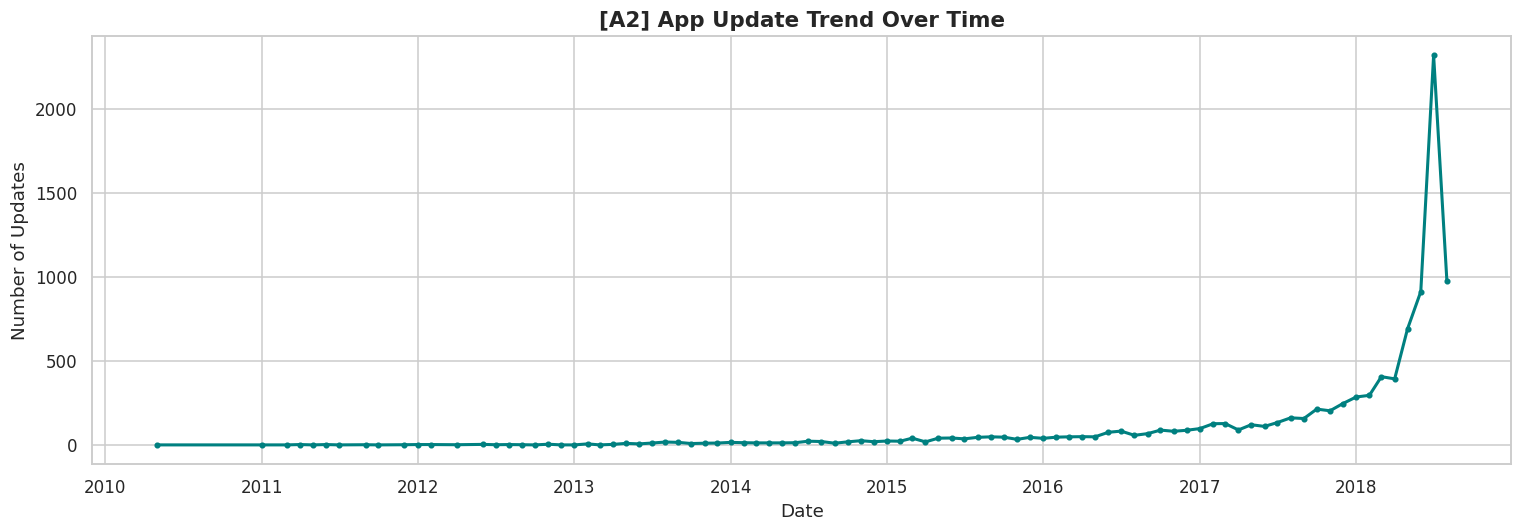


[A2] Update trend plotted → a2_update_trend.png


In [ ]:
#  Trend of app updates over time
update_trend = (
    df.dropna(subset=["Last Updated"])
    .groupby(["Update_Year", "Update_Month"])
    .size()
    .reset_index(name="App_Count")
)
update_trend["Date"] = pd.to_datetime(
    update_trend[["Update_Year", "Update_Month"]].rename(
        columns={"Update_Year": "year", "Update_Month": "month"}
    ).assign(day=1)
)
update_trend = update_trend.sort_values("Date")

plt.figure(figsize=(14, 5))
plt.plot(update_trend["Date"], update_trend["App_Count"],
         color="teal", linewidth=2, marker="o", markersize=3)
plt.title("[A2] App Update Trend Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Number of Updates")
plt.tight_layout()
plt.savefig("a2_update_trend.png", bbox_inches="tight")
plt.show()
print("\n[A2] Update trend plotted → a2_update_trend.png")

In [ ]:
  #. Avg Rating by Install Bins (Binned Analysis)
df["Install_Bin"] = pd.cut(
    df["Installs"],
    bins=[0, 1e3, 1e5, 1e6, 1e7, 1e8, np.inf],
    labels=["<1K", "1K–100K", "100K–1M", "1M–10M", "10M–100M", "100M+"]
)
bin_rating = (
    df.groupby("Install_Bin", observed=False)["Rating"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "Avg_Rating", "count": "App_Count"})
)
print(f"\n[A3] Average Rating by Install Bins:")
print(bin_rating.to_string(index=False))


[A3] Average Rating by Install Bins:
Install_Bin  Avg_Rating  App_Count
        <1K    4.198129       1336
    1K–100K    4.064867       2963
    100K–1M    4.203804       1919
     1M–10M    4.271049       1544
   10M–100M    4.359231        390
      100M+    4.302273         44


In [ ]:
#  Sentiment Analysis (Placeholder)
print("""
[A4] Sentiment Analysis on Reviews:
  ℹ️  The 'googleplaystore.csv' dataset does not contain review TEXT.
     A separate file 'googleplaystore_user_reviews.csv' (also on Kaggle)
     is needed for this analysis.

  If you have that file, here's the code:

  from textblob import TextBlob
  reviews_df = pd.read_csv("googleplaystore_user_reviews.csv")
  reviews_df.dropna(subset=["Translated_Review"], inplace=True)
  reviews_df["Sentiment_Score"] = reviews_df["Translated_Review"].apply(
      lambda x: TextBlob(str(x)).sentiment.polarity
  )
  print(reviews_df[["App","Translated_Review","Sentiment_Score"]].head())
  # Then merge with df on 'App' for combined analysis.
""")


[A4] Sentiment Analysis on Reviews:
  ℹ️  The 'googleplaystore.csv' dataset does not contain review TEXT.
     A separate file 'googleplaystore_user_reviews.csv' (also on Kaggle)
     is needed for this analysis.
 
  If you have that file, here's the code:
 
  from textblob import TextBlob
  reviews_df = pd.read_csv("googleplaystore_user_reviews.csv")
  reviews_df.dropna(subset=["Translated_Review"], inplace=True)
  reviews_df["Sentiment_Score"] = reviews_df["Translated_Review"].apply(
      lambda x: TextBlob(str(x)).sentiment.polarity
  )
  print(reviews_df[["App","Translated_Review","Sentiment_Score"]].head())
  # Then merge with df on 'App' for combined analysis.



In [ ]:
#  Genre vs User Ratings
genre_rating = (
    df.groupby("Genres")["Rating"]
    .agg(["mean", "median", "count"])
    .reset_index()
    .rename(columns={"mean": "Mean_Rating", "median": "Median_Rating", "count": "App_Count"})
    .query("App_Count >= 10")
    .sort_values("Mean_Rating", ascending=False)
)
print(f"\n[A5] Top 10 Genres by Mean Rating (min 10 apps):")
print(genre_rating.head(10).to_string(index=False))


[A5] Top 10 Genres by Mean Rating (min 10 apps):
                Genres  Mean_Rating  Median_Rating  App_Count
    Casual;Brain Games     4.475000            4.5         12
                Events     4.435556            4.5         45
    Puzzle;Brain Games     4.370588            4.4         17
                Puzzle     4.370000            4.4        100
Education;Pretend Play     4.358824            4.3         17
          Art & Design     4.358182            4.4         55
     Books & Reference     4.344970            4.5        169
                  Word     4.340909            4.3         22
     Board;Brain Games     4.340000            4.3         15
             Parenting     4.340000            4.5         40


In [ ]:
 # FINAL SUMMARY

print("\n" + "=" * 55)
print(" KEY INSIGHTS SUMMARY")
print("=" * 55)
print(f"Total Apps (cleaned)         : {df.shape[0]:,}")
print(f"Unique Categories            : {df['Category'].nunique()}")
print(f"Average Rating               : {df['Rating'].mean():.2f}")
print(f"% Free Apps                  : {(df['Type']=='Free').mean()*100:.1f}%")
print(f"Most Common Content Rating   : {df['Content Rating'].mode()[0]}")
print(f"Average App Size             : {df['Size'].mean():.1f} MB")
print(f"Apps Updated in 2018         : {len(df[df['Update_Year']==2018]):,}")
print(f"Apps with Rating ≥ 4.0       : {len(df[df['Rating']>=4.0]):,}")
print(f"Installs–Rating Correlation  : {corr_val:.4f}")


 KEY INSIGHTS SUMMARY
Total Apps (cleaned)         : 9,659
Unique Categories            : 33
Average Rating               : 4.17
% Free Apps                  : 92.2%
Most Common Content Rating   : Everyone
Average App Size             : 20.4 MB
Apps Updated in 2018         : 6,284
Apps with Rating ≥ 4.0       : 6,286
Installs–Rating Correlation  : 0.0401
